In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gc

SIM_DIR     = Path("/nvme1/users/md962/glacier/Glacier Project/Sim_Merged/")
MODELS_DIR  = Path("/nvme1/users/md962/glacier/Glacier Project/Final_Models/")
RESULTS_DIR = Path("/nvme1/users/md962/glacier/Glacier Project/Results/")
PARQUET_DIR = Path("/nvme1/users/md962/glacier/Glacier Project/Merged/")
RGI_PATH    = Path("/nvme1/users/md962/glacier/Glacier Project/rgi70_peru.geojson")

AE_COLS            = [f'A{i:02d}' for i in range(64)]
DEVICE             = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIXEL_AREA         = (10 * 10) / 1e6        # km²
TIMESTEP           = 10                     # years
ANNUAL_PIXELS_LOST = 1_736_128 // 8        # = 217,016 pixels/year from observed data
PIXELS_PER_STEP    = ANNUAL_PIXELS_LOST * TIMESTEP  # pixels lost per 10-year timestep
START_YEAR         = 2025
END_YEAR           = 2085
TIMESTEPS          = list(range(START_YEAR, END_YEAR + 1, TIMESTEP))
MIN_GLACIER_KM2    = 0.01

print(f"Device: {DEVICE}")
print(f"Annual pixels lost: {ANNUAL_PIXELS_LOST:,} ({ANNUAL_PIXELS_LOST * PIXEL_AREA:.2f} km²/year)")
print(f"Per 10yr step:      {PIXELS_PER_STEP:,} ({PIXELS_PER_STEP * PIXEL_AREA:.2f} km²)")
print(f"Timesteps: {TIMESTEPS}")

Device: cuda
Annual pixels lost: 217,016 (21.70 km²/year)
Per 10yr step:      2,170,160 (217.02 km²)
Timesteps: [2025, 2035, 2045, 2055, 2065, 2075, 2085]


In [2]:
print("Loading 2025 simulation parquets...")
dfs = []
for region in ['r3', 'r1a', 'r1b', 'r2']:
    df = pd.read_parquet(SIM_DIR / f'sim_2025_{region}.parquet')
    df['region'] = region
    dfs.append(df)

df_sim = pd.concat(dfs, ignore_index=True)
df_sim = df_sim.drop_duplicates(subset=['lon', 'lat'], keep='first').reset_index(drop=True)
print(f"2025 pixels: {len(df_sim):,}")
print(f"Starting ice area: {len(df_sim) * PIXEL_AREA:.2f} km²")

Loading 2025 simulation parquets...
2025 pixels: 12,260,700
Starting ice area: 1226.07 km²


In [3]:
print("Loading RGI outlines...")
rgi = gpd.read_file(RGI_PATH)[['rgi_id', 'geometry']]
print(f"RGI glaciers: {len(rgi):,}")

print("Running spatial join...")
geometry  = gpd.points_from_xy(df_sim['lon'], df_sim['lat'])
gdf_sim   = gpd.GeoDataFrame(df_sim[['lon', 'lat']], geometry=geometry, crs='EPSG:4326')
joined    = gpd.sjoin(gdf_sim, rgi, how='left', predicate='within')
df_sim['rgi_id'] = joined['rgi_id'].values

n_matched = df_sim['rgi_id'].notna().sum()
print(f"Matched:   {n_matched:,} ({n_matched/len(df_sim)*100:.1f}%)")
print(f"Unmatched: {df_sim['rgi_id'].isna().sum():,} — excluded (buffer pixels outside RGI)")

# Keep only RGI-matched pixels
df_matched = df_sim[df_sim['rgi_id'].notna()].reset_index(drop=True)
print(f"\nSimulation pixels: {len(df_matched):,}")
print(f"Unique glaciers:   {df_matched['rgi_id'].nunique():,}")
print(f"Starting ice area (RGI-matched): {len(df_matched) * PIXEL_AREA:.2f} km²")

Loading RGI outlines...
RGI glaciers: 3,695
Running spatial join...
Matched:   11,470,589 (93.6%)
Unmatched: 790,111 — excluded (buffer pixels outside RGI)

Simulation pixels: 11,470,589
Unique glaciers:   2,380
Starting ice area (RGI-matched): 1147.06 km²


In [5]:
# Apply minimum glacier size filter
glacier_sizes = df_matched.groupby('rgi_id').size() * PIXEL_AREA
valid_glaciers = glacier_sizes[glacier_sizes >= MIN_GLACIER_KM2].index
df_matched = df_matched[df_matched['rgi_id'].isin(valid_glaciers)].reset_index(drop=True)

print(f"\nAfter minimum size filter ({MIN_GLACIER_KM2} km²):")
print(f"  Valid glaciers: {df_matched['rgi_id'].nunique():,}")
print(f"  Valid pixels:   {len(df_matched):,}")
print(f"  Ice area:       {len(df_matched) * PIXEL_AREA:.2f} km²")


After minimum size filter (0.01 km²):
  Valid glaciers: 1,996
  Valid pixels:   11,453,364
  Ice area:       1145.34 km²


In [6]:
class GlacierMLP(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

mlp_model = GlacierMLP(dropout=0.5).to(DEVICE)
mlp_model.load_state_dict(torch.load(
    MODELS_DIR / 'MLP_AE64_R3HOLDOUT.pt', weights_only=True))
mlp_model.eval()
print("MLP loaded ✓")

def compute_scores(embeddings_np, batch_size=65536):
    embeddings = torch.from_numpy(embeddings_np).to(DEVICE)
    scores = []
    with torch.no_grad():
        for start in range(0, len(embeddings), batch_size):
            logits = mlp_model(embeddings[start:start+batch_size])
            scores.extend(torch.sigmoid(logits).cpu().numpy())
    del embeddings
    torch.cuda.empty_cache()
    return np.array(scores, dtype=np.float32)

print("Computing vulnerability scores for all 2025 pixels...")
scores = compute_scores(df_matched[AE_COLS].values.astype(np.float32))
print(f"Scores computed: {len(scores):,}")
print(f"Score distribution: min={scores.min():.4f}, "
      f"mean={scores.mean():.4f}, max={scores.max():.4f}")

MLP loaded ✓
Computing vulnerability scores for all 2025 pixels...
Scores computed: 11,453,364
Score distribution: min=0.0000, mean=0.1828, max=1.0000


In [17]:
def run_simulation(df_start, scores, timesteps):
    """
    Iterative glacier melt simulation using global MLP vulnerability ranking.
    
    At each 10-year timestep, a fixed number of pixels (PIXELS_PER_STEP,
    calibrated from observed 2017-2025 retreat of 217,016 pixels/year) are
    designated as melted, selected by MLP vulnerability score.
    The model determines WHICH pixels melt; the rate is anchored to 
    observed 2017-2025 retreat (-34.3 km²/year, consistent with 
    Seehaus et al. 2019 and INAIGEM linear extrapolation methodology).
    
    Returns area history and per-pixel melt timestep assignments.
    """
    surviving    = np.ones(len(df_start), dtype=bool)
    melt_year    = np.zeros(len(df_start), dtype=np.int32)
    area_history = [(timesteps[0], surviving.sum() * PIXEL_AREA)]
    
    for t_idx in range(len(timesteps) - 1):
        year      = timesteps[t_idx]
        next_year = timesteps[t_idx + 1]
        n_current = surviving.sum()
        
        # Fixed absolute pixel loss per step — not proportional
        # min() ensures we don't melt more pixels than remain
        n_melt = min(n_current, PIXELS_PER_STEP)
        
        # Global rank: select top N most vulnerable surviving pixels
        surv_idx    = np.where(surviving)[0]
        surv_scores = scores[surv_idx]
        top_local   = np.argsort(surv_scores)[::-1][:n_melt]
        top_global  = surv_idx[top_local]
        
        surviving[top_global] = False
        melt_year[top_global] = next_year
        
        ice_area = surviving.sum() * PIXEL_AREA
        area_history.append((next_year, ice_area))
        
        pct_lost = (1 - ice_area / (len(df_start) * PIXEL_AREA)) * 100
        print(f"  {year}→{next_year}: {surviving.sum():,} pixels remaining, "
              f"{ice_area:.2f} km² ({pct_lost:.1f}% lost from 2025)")
    
    df_out = df_start[['lon', 'lat', 'rgi_id', 'region']].copy()
    df_out['melt_year'] = melt_year  # 0 = survives to end of simulation
    
    return area_history, df_out

# Updated call — no melt_per_step argument
start_area = len(df_matched) * PIXEL_AREA
print(f"Starting ice area: {start_area:.2f} km²\n")
print("=== RUNNING SIMULATION ===")
area_history, results_df = run_simulation(df_matched, scores, TIMESTEPS)
print("\nSimulation complete")

Starting ice area: 1145.34 km²

=== RUNNING SIMULATION ===
  2025→2035: 9,283,204 pixels remaining, 928.32 km² (18.9% lost from 2025)
  2035→2045: 7,113,044 pixels remaining, 711.30 km² (37.9% lost from 2025)
  2045→2055: 4,942,884 pixels remaining, 494.29 km² (56.8% lost from 2025)
  2055→2065: 2,772,724 pixels remaining, 277.27 km² (75.8% lost from 2025)
  2065→2075: 602,564 pixels remaining, 60.26 km² (94.7% lost from 2025)
  2075→2085: 0 pixels remaining, 0.00 km² (100.0% lost from 2025)

Simulation complete


In [18]:
print("\n=== PROJECTION RESULTS ===\n")
print(f"{'Year':<6} {'Ice Area (km²)':>15} {'Loss (km²)':>12} {'Loss %':>8}")
print("-" * 45)

for year, area in area_history:
    loss_km2 = start_area - area
    loss_pct = loss_km2 / start_area * 100
    print(f"{year:<6} {area:>15.2f} {loss_km2:>12.2f} {loss_pct:>7.1f}%")


=== PROJECTION RESULTS ===

Year    Ice Area (km²)   Loss (km²)   Loss %
---------------------------------------------
2025           1145.34         0.00     0.0%
2035            928.32       217.02    18.9%
2045            711.30       434.03    37.9%
2055            494.29       651.05    56.8%
2065            277.27       868.06    75.8%
2075             60.26      1085.08    94.7%
2085              0.00      1145.34   100.0%


In [19]:
print("\n=== PER-GLACIER SURVIVAL ANALYSIS ===\n")

glacier_stats = []
for rgi_id, grp in results_df.groupby('rgi_id'):
    n_pixels      = len(grp)
    area_2025     = n_pixels * PIXEL_AREA
    
    # Find first timestep where glacier drops below MIN_GLACIER_KM2
    disappear_year = None
    for year, _ in area_history[1:]:
        n_surviving = ((grp['melt_year'] == 0) | (grp['melt_year'] > year)).sum()
        area = n_surviving * PIXEL_AREA
        if area < MIN_GLACIER_KM2:
            disappear_year = year
            break
    
    # Compute area at each timestep
    areas = {}
    for year, _ in area_history:
        n_surv = ((grp['melt_year'] == 0) | (grp['melt_year'] > year)).sum()
        areas[year] = n_surv * PIXEL_AREA
    
    # Mean vulnerability score
    glacier_idx   = grp.index
    mean_score    = scores[glacier_idx].mean()
    
    glacier_stats.append({
        'rgi_id':        rgi_id,
        'area_2025_km2': area_2025,
        'mean_score':    mean_score,
        'disappear_year': disappear_year,
        **{f'area_{y}': areas[y] for y in TIMESTEPS}
    })

df_glaciers = pd.DataFrame(glacier_stats)
df_glaciers = df_glaciers.sort_values('mean_score', ascending=False).reset_index(drop=True)

# Summary
n_total   = len(df_glaciers)
for target in [2035, 2045, 2055, 2065, 2075, 2085]:
    n_gone = (df_glaciers['disappear_year'] <= target).sum()
    print(f"Glaciers disappeared by {target}: {n_gone:,} / {n_total:,} "
          f"({n_gone/n_total*100:.1f}%)")

print(f"\nGlaciers surviving to 2085: "
      f"{df_glaciers['disappear_year'].isna().sum():,} "
      f"({df_glaciers['disappear_year'].isna().sum()/n_total*100:.1f}%)")

print(f"\nTop 10 most vulnerable glaciers:")
print(df_glaciers[['rgi_id', 'area_2025_km2', 'mean_score', 
                    'disappear_year']].head(10).to_string(index=False))


=== PER-GLACIER SURVIVAL ANALYSIS ===

Glaciers disappeared by 2035: 416 / 1,996 (20.8%)
Glaciers disappeared by 2045: 729 / 1,996 (36.5%)
Glaciers disappeared by 2055: 998 / 1,996 (50.0%)
Glaciers disappeared by 2065: 1,308 / 1,996 (65.5%)
Glaciers disappeared by 2075: 1,762 / 1,996 (88.3%)
Glaciers disappeared by 2085: 1,996 / 1,996 (100.0%)

Glaciers surviving to 2085: 0 (0.0%)

Top 10 most vulnerable glaciers:
                 rgi_id  area_2025_km2  mean_score  disappear_year
RGI2000-v7.0-G-16-01028         0.0150    0.998616            2035
RGI2000-v7.0-G-16-00696         0.0103    0.995087            2035
RGI2000-v7.0-G-16-02261         0.0112    0.994697            2035
RGI2000-v7.0-G-16-02029         0.0154    0.992768            2035
RGI2000-v7.0-G-16-01087         0.0141    0.989916            2035
RGI2000-v7.0-G-16-01173         0.0310    0.988484            2035
RGI2000-v7.0-G-16-00954         0.0105    0.988310            2035
RGI2000-v7.0-G-16-00152         0.0104    0.9

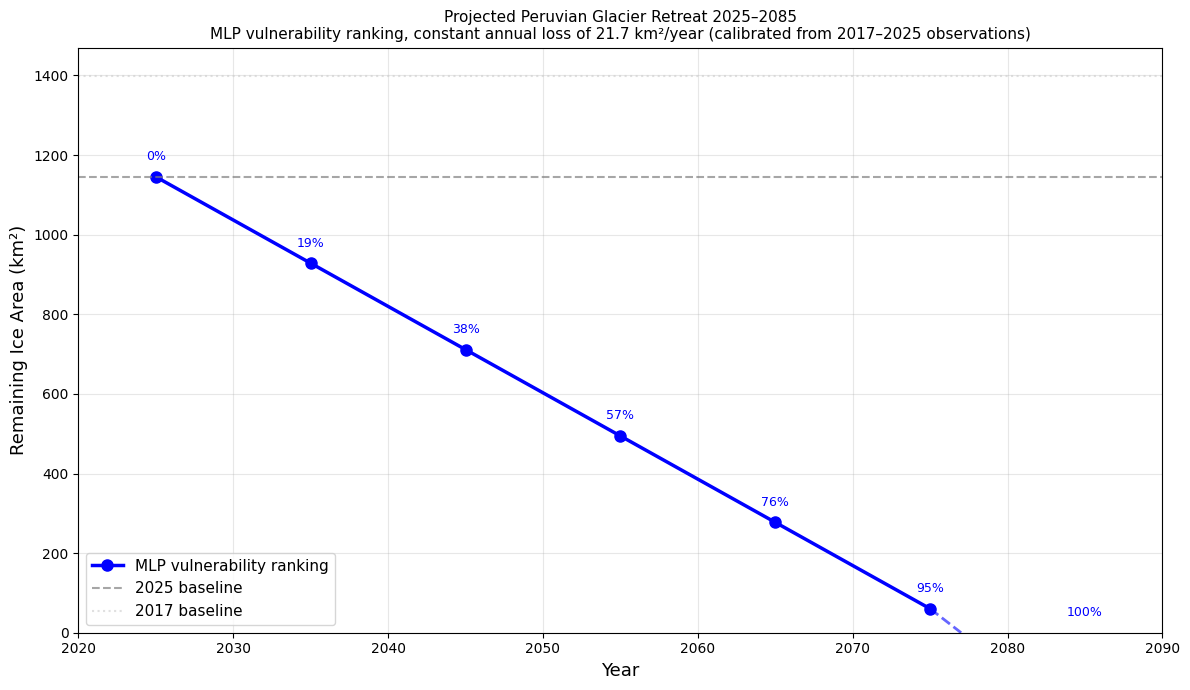

Plot saved


In [23]:
fig, ax = plt.subplots(figsize=(12, 7))

years = [y for y, _ in area_history]
areas = [a for _, a in area_history]

# Find the year of complete deglaciation
deglaciation_year = None
for year, area in area_history:
    if area <= 0:
        deglaciation_year = year
        break

# If not complete within simulation, extrapolate
if deglaciation_year is None:
    last_area = areas[-1]
    last_year = years[-1]
    deglaciation_year = last_year + int(last_area / (ANNUAL_PIXELS_LOST * PIXEL_AREA))

# Remove the last point from the solid line if it causes gradient change
# Find where the gradient changes (last real step vs truncated step)
full_step_area = PIXELS_PER_STEP * PIXEL_AREA

# Check if last step was truncated
if len(areas) >= 2:
    last_step = areas[-2] - areas[-1]
    step_truncated = last_step < full_step_area * 0.95  # truncated if < 95% of full step

if step_truncated:
    # Plot solid line only up to second-to-last point
    ax.plot(years[:-1], areas[:-1], 'b-o', linewidth=2.5, markersize=8,
            label='MLP vulnerability ranking')
    # Extrapolate from second-to-last point to zero
    second_last_year = years[-2]
    second_last_area = areas[-2]
    years_to_zero = second_last_area / full_step_area * TIMESTEP
    deglaciation_year = int(second_last_year + years_to_zero)
    ax.plot([second_last_year, deglaciation_year], [second_last_area, 0],
            'b--', linewidth=2.0, alpha=0.6)
else:
    ax.plot(years, areas, 'b-o', linewidth=2.5, markersize=8,
            label='MLP vulnerability ranking')
    deglaciation_year = years[-1]

ax.axhline(y=start_area, color='gray', linestyle='--',
           alpha=0.7, label='2025 baseline')
ax.axhline(y=13_996_828 * PIXEL_AREA, color='lightgray',
           linestyle=':', alpha=0.7, label='2017 baseline')

# Annotate each solid point
for year, area in area_history:
    loss_pct = (start_area - area) / start_area * 100
    ax.annotate(f'{loss_pct:.0f}%',
                xy=(year, area),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9, color='blue')

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Remaining Ice Area (km²)', fontsize=13)
ax.set_title('Projected Peruvian Glacier Retreat 2025–2085\n'
             'MLP vulnerability ranking, constant annual loss of '
             f'{ANNUAL_PIXELS_LOST * PIXEL_AREA:.1f} km²/year '
             '(calibrated from 2017–2025 observations)',
             fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(2020, max(deglaciation_year + 5, 2090))
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'glacier_retreat_projection.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [24]:
# Save per-pixel melt years
results_df.to_parquet(RESULTS_DIR / 'simulation_melt_years.parquet', index=False)

# Save per-glacier stats
df_glaciers.to_parquet(RESULTS_DIR / 'glacier_survival_stats.parquet', index=False)

# Save area history
df_history = pd.DataFrame(area_history, columns=['year', 'ice_area_km2'])
df_history['ice_loss_km2'] = start_area - df_history['ice_area_km2']
df_history['ice_loss_pct'] = df_history['ice_loss_km2'] / start_area * 100
df_history.to_parquet(RESULTS_DIR / 'simulation_area_history.parquet', index=False)

print("All results saved")
print(f"\nKey headline figures:")
for year, area in area_history:
    loss = (start_area - area) / start_area * 100
    print(f"  {year}: {area:.2f} km² ({loss:.1f}% lost from 2025)")

All results saved

Key headline figures:
  2025: 1145.34 km² (0.0% lost from 2025)
  2035: 928.32 km² (18.9% lost from 2025)
  2045: 711.30 km² (37.9% lost from 2025)
  2055: 494.29 km² (56.8% lost from 2025)
  2065: 277.27 km² (75.8% lost from 2025)
  2075: 60.26 km² (94.7% lost from 2025)
  2085: 0.00 km² (100.0% lost from 2025)
